# Package 5 — The follow-up paradox

The sales manager claims: **"After the 3rd follow-up call, we're just wasting time."**

Question: is that true? Build the dropout rate at each follow-up stage
(`followup_1` → `followup_5`), visualize it, and give a data-driven recommendation.

Questions to answer:
1. At which stage does dropout behave unexpectedly?
2. For deals that eventually closed, how many follow-ups did they typically take?
3. Should Northbound change its follow-up policy — yes or no, and why?

**Funnel structure (confirmed):** `leads_answered → followup_1 → followup_2 →
followup_3 → followup_4 → followup_5 → (closed + not_closed)`. Each column is how
many leads *remained* (not yet closed, not yet given up on) after that round of
calls. Confirmed `followup_5 == not_closed + closed` in every row checked.

## Dropout rate per stage

Dropout at stage *i* = the share of leads present *before* that round who did **not**
make it to the next round (some closed, some were dropped as `not_closed` — at this
stage we can't tell which, we only see the pool shrink).

Stage boundaries:
- Stage 1: `leads_answered` → `followup_1`
- Stage 2: `followup_1` → `followup_2`
- Stage 3: `followup_2` → `followup_3`
- Stage 4: `followup_3` → `followup_4`
- Stage 5: `followup_4` → `followup_5`

Computed **per row** (per campaign), then averaged — this weighs every campaign
equally regardless of size, which matches "how does dropout behave for a typical
campaign" better than pooling raw counts (which would let a few huge campaigns
dominate the average).

In [1]:
import pandas as pd

df = pd.read_csv("../data/funnel_marketing_data.csv")

stages = ["leads_answered", "followup_1", "followup_2", "followup_3", "followup_4", "followup_5"]

dropout = pd.DataFrame(index=df.index)
for i in range(1, len(stages)):
    prev_col, cur_col = stages[i - 1], stages[i]
    dropout[f"stage_{i}"] = (df[prev_col] - df[cur_col]) / df[prev_col]

dropout.describe().loc[["mean", "std", "min", "max"]]

,stage_1,stage_2,stage_3,stage_4,stage_5
mean,0.225080,0.259098,0.187345,0.102856,0.297836
std,0.039444,0.044258,0.055705,0.062470,0.072537
min,0.103448,0.000000,0.000000,0.000000,0.000000
max,0.400000,0.500000,0.500000,0.500000,0.500000


## Visualizing dropout per stage

Same aggregate-based dropout rates, plotted as a bar chart — this is the artifact the
brief asks to expose in the dashboard.

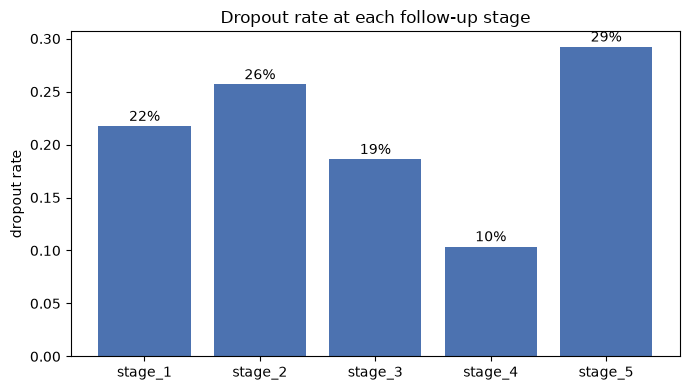

In [2]:
import matplotlib.pyplot as plt

sums = df[stages].sum()
stage_dropout = pd.Series(
    {f"stage_{i}": (sums[stages[i - 1]] - sums[stages[i]]) / sums[stages[i - 1]] for i in range(1, 6)}
)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(stage_dropout.index, stage_dropout.values, color="#4C72B0")
ax.set_ylabel("dropout rate")
ax.set_title("Dropout rate at each follow-up stage")
for bar, val in zip(bars, stage_dropout.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.005, f"{val:.0%}", ha="center")
plt.tight_layout()
plt.show()

## Question 2 — how many follow-ups did closed deals typically take?

The dropout-per-stage view tells us about the whole pool, but doesn't directly say
how many calls a deal that *succeeded* actually needed. For that we use
`calls_to_closed`, which the dataset already tracks per row (average calls before
closing, for that row's closed deals) — no need to re-derive it from the
`followup_1..5` columns.

**Data-quality catch first:** rows where `closed == 0` (no deal closed at all) have
`calls_to_closed == 0` — that's not a real "0 calls to close," it's a placeholder for
an undefined average (there's nothing to average when nothing closed). Including
those 182 rows would drag the distribution down artificially. Filtering to
`closed > 0` (3,318 rows) before looking at `calls_to_closed`.

In [3]:
closed_deals = df[df["closed"] > 0]
closed_deals["calls_to_closed"].describe()

count    3318.000000
mean        3.706148
std         1.654376
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max         9.000000
Name: calls_to_closed, dtype: float64

In [4]:
closed_deals["calls_to_closed"].value_counts().sort_index()

calls_to_closed
1      91
2    1034
3     598
4     356
5     690
6     395
7     133
8      20
9       1
Name: count, dtype: int64

## One more angle — does more calls mean less valuable deals?

The dropout and call-count views tell us about *volume*. But the sales manager's
real complaint is about *value* — "wasting time" implies the later calls aren't
worth the effort. So: for closed deals, does profit-per-deal change with how many
calls it took?

In [5]:
closed_deals["profit_per_deal"] = closed_deals["cumulative_profit"] / closed_deals["closed"]

profit_by_calls = closed_deals.groupby("calls_to_closed")["profit_per_deal"].agg(["mean", "count"])
print(profit_by_calls)
print()
print("correlation(calls_to_closed, profit_per_deal):", closed_deals["calls_to_closed"].corr(closed_deals["profit_per_deal"]))

                        mean  count
calls_to_closed                    
1                8265.155966     88
2                8176.063539   1030
3                6278.347340    589
4                2255.444015    352
5                1833.268054    684
6                1384.364849    393
7                1651.718045    133
8                1579.000000     20
9                1135.000000      1

correlation(calls_to_closed, profit_per_deal): -0.6089898387897577


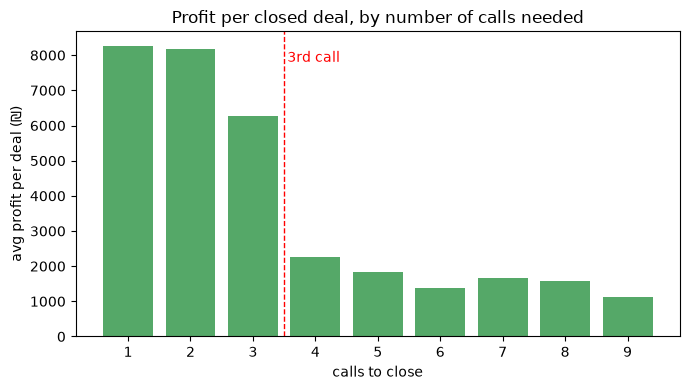

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(profit_by_calls.index.astype(str), profit_by_calls["mean"], color="#55A868")
ax.set_xlabel("calls to close")
ax.set_ylabel("avg profit per deal (₪)")
ax.set_title("Profit per closed deal, by number of calls needed")
ax.axvline(2.5, color="red", linestyle="--", linewidth=1)
ax.text(2.55, ax.get_ylim()[1]*0.9, "3rd call", color="red")
plt.tight_layout()
plt.show()

## Answering the founder's questions

**1. At which stage does dropout behave unexpectedly?**
Dropout is *not* monotonically increasing, which is what the manager's claim
implicitly assumes. Stage 3→4 (3rd→4th call) has the **lowest** dropout of all five
stages (10%, even lower than stage 1's 22%) — leads who survive to the 3rd call are
unusually likely to survive the 4th too. Then stage 4→5 **spikes to 30%**, the
highest of any stage. The surprise isn't "after call 3" — it's specifically the
gap between the 4th and 5th call.

**2. For deals that eventually closed, how many follow-ups did they typically take?**
It's bimodal, not a single "typical" number: ~31% of closed deals (1,034 of 3,318)
closed in just 2 calls, but a real second cluster — ~21% (690 deals) — needed the
full 5 calls. Cutting off at call 3 would forfeit that whole second cluster, not just
a fringe.

**3. Should Northbound change its follow-up policy — yes or no, and why?**
**No, not a hard cutoff — but the manager's instinct about value isn't wrong either.**
Profit-per-deal drops off a cliff right after call 3: ₪6,278 avg at call 3 vs.
₪2,255 at call 4 (−64%), and keeps falling (r = −0.61 between calls-to-close and
profit-per-deal). So the *manager is right that later calls close lower-value deals*
— but *wrong that they're worthless*: those deals still close, and they're a fifth
of total deal volume. A blanket "stop after call 3" throws away real (if smaller)
revenue.

**Recommendation:** replace the blanket call-count rule with a scored one. Don't
follow up with everyone through 5 calls, and don't cut everyone off at 3 — use the
LTV / upsell / super-customer models already built in Packages 2–4 to prioritize
*which* leads are worth chasing past call 3 (the ones that look high-value early
on), rather than applying the same cutoff to every lead regardless of quality. This
is consistent with the cross-package pattern that "quality of close" (fewer calls
needed) predicts higher customer value — the fix isn't fewer calls for everyone,
it's smarter targeting of who gets them.